# Counting - Images

## Setup

Set up `sys.path` to work while within a subfolder.

In [1]:
import sys
sys.path.append("../..")

Enable this if working within VSCode.

In [2]:
import os

if not os.environ.get("NOTEBOOK_PATH"):
    os.environ["NOTEBOOK_PATH"] = "notebooks/part-1/counting.ipynb"

Manim-related imports.

In [3]:
from manim import *
from manim_utils import *

Set up the image generation cell magic.

In [4]:
%load_ext magics.generate_image

Loaded extension.


## Scenes

### The Counting of Five Items
The dialogue at the start of the chapter.

Common constants for the scenes.

In [5]:
ITEM_CLASSES = [Circle, Star, Triangle, Square, RegularPolygon]
ITEM_COLOURS = [RED, BLUE, GREEN, ORANGE, GRAY]
ITEM_RADIUS = 0.75
ITEM_SPACING = 2

LABEL_SHIFT = 1.25  # Downwards

Helper functions to set up items and labels.

In [6]:
def create_items() -> VGroup:
    items = []
    for i in range(5):
        cls = ITEM_CLASSES[i]
        if cls == Circle:
            item = cls(radius=ITEM_RADIUS)
        elif cls == Square:
            item = cls(side_length=ITEM_RADIUS * 2)
        elif cls == Star:
            item = cls(outer_radius=ITEM_RADIUS)
        elif cls == Triangle or cls == RegularPolygon:
            if cls == Triangle:
                item = RegularPolygon(n=3)
            else:
                item = RegularPolygon(n=6)
            item = cls().scale(ITEM_RADIUS)
        else:
            raise ValueError(f"Unknown class {cls}")
        item.set_color(ITEM_COLOURS[i])
        item.set_fill(ITEM_COLOURS[i], opacity=0.25)
        item.move_to((i-2) * ITEM_SPACING * RIGHT)
        items.append(item)

    return VGroup(*items)

In [7]:
def create_labels(items: VGroup, labels: list[tuple[int, ...]]) -> VGroup:
    assert len(labels) == 5

    label_objects = []
    for i, item in enumerate(items):
        the_labels = labels[i]
        if len(the_labels) == 0:
            continue
            
        label = Text(f"{', '.join([str(x) for x in the_labels])}", color=BLACK)
        label.move_to(item)
        label.shift(LABEL_SHIFT * DOWN)
        label_objects.append(label)

    return VGroup(*label_objects)

Just the items.

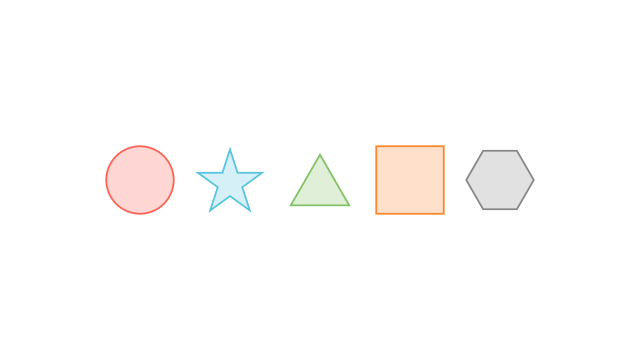

In [8]:
%%generate_image five-count_items-only CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        items = create_items()
        self.add(items)

Non-injective, non-surjective counting.

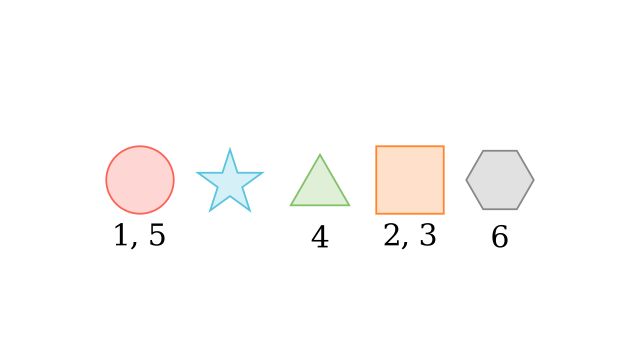

In [9]:
%%generate_image five-count_noninj-nonsurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,5),
            (),
            (4,),
            (2,3),
            (6,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Injective, non-surjective counting.

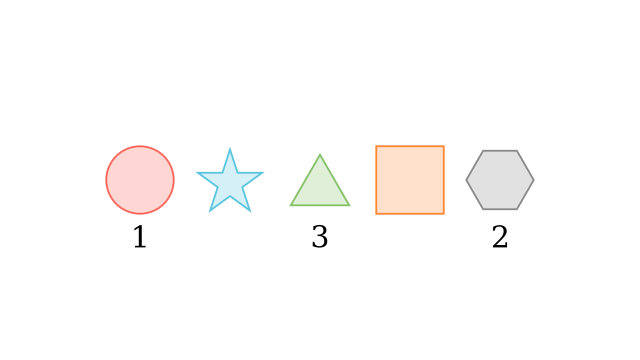

In [10]:
%%generate_image five-count_yesinj-nonsurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (),
            (3,),
            (),
            (2,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Disregarding stars.

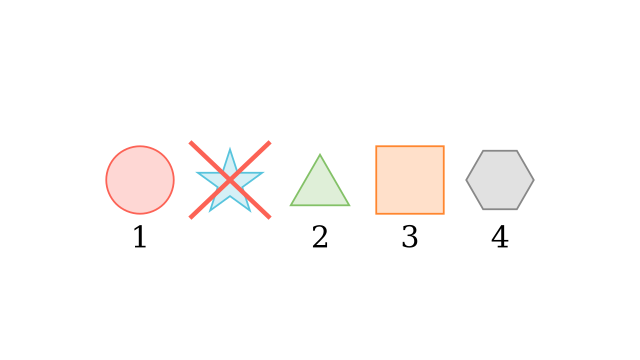

In [11]:
%%generate_image five-count_no-star CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (),
            (2,),
            (3,),
            (4,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)
        
        # Cross out the star
        cross = Cross(items[1], stroke_width=10.0, scale_factor=1.25)  # Which is the star
        self.add(cross)


Non-injective, surjective counting.

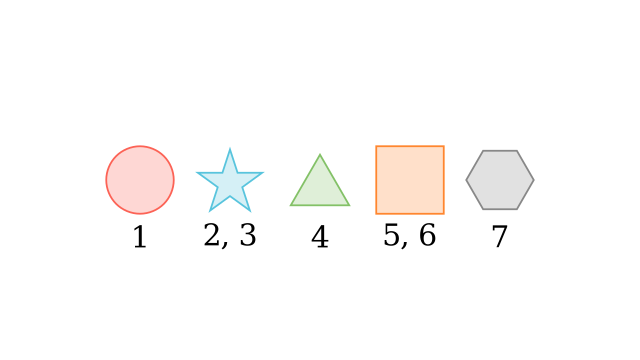

In [12]:
%%generate_image five-count_noninj-yessurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (2,3),
            (4,),
            (5,6),
            (7,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

Injective, surjective counting.

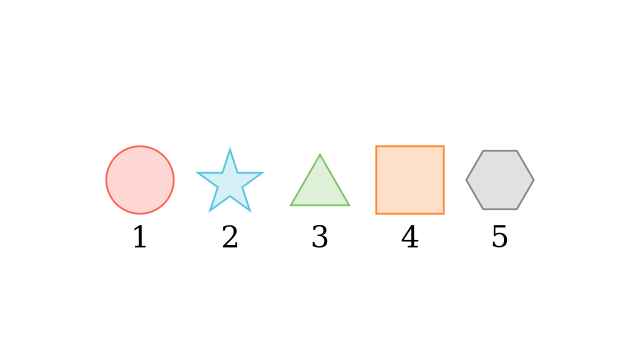

In [13]:
%%generate_image five-count_yesinj-yessurj CountingDiagram

class CountingDiagram(Scene):
    def construct(self):
        # Set up the five items
        items = create_items()
        self.add(items)

        # Add the labels
        labels = [
            (1,),
            (2,),
            (3,),
            (4,),
            (5,)
        ]
        labels = create_labels(items, labels)
        self.add(labels)

### Equinumerous Sets

The function $f$ where
$$
    f = \{(a, w), (b, x), (c, y), (d, z)\}.
$$

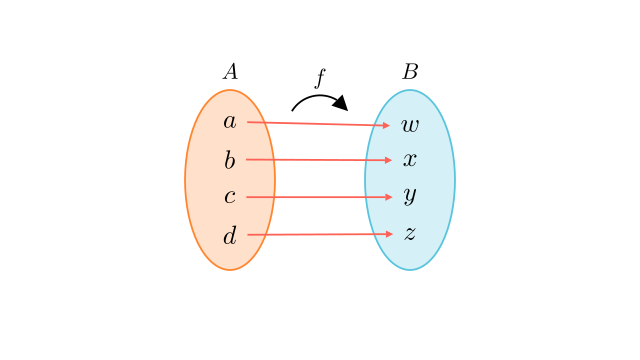

In [14]:
%%generate_image equinumerous-sets_f FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * RIGHT)

        self.add(ellipse_a, ellipse_b)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)

        self.add(label_a, label_b)

        # Add function label
        f_label = MathTex("f", color=BLACK).move_to(2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d"]
        elements_b = ["w", "x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows
        arrow_links = [(i,i) for i in range(4)]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

The function $g$ where
$$
    g = \{(a, z), (b, x), (c, w), (d, y)\}.
$$

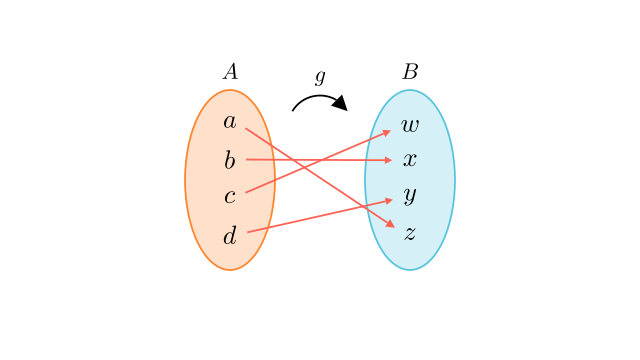

In [15]:
%%generate_image equinumerous-sets_g FunctionDiagram

A_FONT_SIZE = 56  # TeX font size
A_COLOUR = ORANGE
B_FONT_SIZE = 56
B_COLOUR = BLUE

ARROW_STROKE_WIDTH = 4
ARROW_TIP_RATIO = 0.05
ARROW_COLOUR = RED

class FunctionDiagram(Scene):
    def construct(self):
        # Create the ellipses
        ellipse_a = Ellipse(width=2, height=4, color=A_COLOUR)
        ellipse_a.set_fill(A_COLOUR, opacity=0.25)
        ellipse_a.shift(2 * LEFT)
        
        ellipse_b = Ellipse(width=2, height=4, color=B_COLOUR)
        ellipse_b.set_fill(B_COLOUR, opacity=0.25)
        ellipse_b.shift(2 * RIGHT)

        self.add(ellipse_a, ellipse_b)
        
        # Create labels for the ellipses
        label_a = MathTex("A", color=BLACK).next_to(ellipse_a, UP)
        label_b = MathTex("B", color=BLACK).next_to(ellipse_b, UP)

        self.add(label_a, label_b)

        # Add function label
        f_label = MathTex("g", color=BLACK).move_to(2.25*UP)
        f_label.add(
            CurvedArrow(
                f_label.get_left() + LEFT * 0.5,
                f_label.get_right() + RIGHT * 0.5,
                stroke_width=ARROW_STROKE_WIDTH,
                color=BLACK
            ).flip(LEFT).shift(DOWN * 0.35)
        )

        self.add(f_label)

        # Create elements for sets
        elements_a = ["a", "b", "c", "d"]
        elements_b = ["w", "x", "y", "z"]

        elements_a = [MathTex(a, font_size=A_FONT_SIZE, color=BLACK) for a in elements_a]
        elements_b = [MathTex(b, font_size=B_FONT_SIZE, color=BLACK) for b in elements_b]
        
        elements_a = VGroup(*elements_a).arrange(DOWN, buff=0.5).move_to(ellipse_a)
        elements_b = VGroup(*elements_b).arrange(DOWN, buff=0.5).move_to(ellipse_b)

        self.add(elements_a, elements_b)
        
        # Create arrows
        arrow_links = [
            (0,3),
            (1,1),
            (2,0),
            (3,2)
        ]
        arrows = [
            Arrow(
                elements_a[i].get_right(),
                elements_b[j].get_left(),
                stroke_width=ARROW_STROKE_WIDTH,
                max_tip_length_to_length_ratio=ARROW_TIP_RATIO,
                color=RED
            )
            for i, j in arrow_links
        ]
        self.add(VGroup(*arrows))

### TODO